Read warptemplates for some class and look at properties of the sample, especially peak color. 

In [1]:
import os, re, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import exponnorm
from pathlib import Path
from datetime import datetime

In [2]:
sys.path.append('/Users/jnordin/github/ampelFeb25')

In [3]:
from warpTemplate import WarpfitTemplateLoader

In [4]:
template_class_id = 6

In [5]:
# Parameters for fit template retrieval
exclude_input = [] # Will reject any warptemplate containing any of these (either as sn or template basis)
# How to define templates?
# - How many templates per sn basis? 
#      * if 'all' it will return one copy of each template, 
#.     * if int it will return that many, drawn according to the template probability, 
#      * if -int it will return that many copies drawn from a uniform probabilitiy
#      Note: draws made with replacement, so multiple copies can be returned if int is larger than the available number of templates (often 3)
template_selection = 3    # Use the same number per SN to keep balance 
# - How many sn basis?
#.     * if 'all', take one of each
#.     * if an int, draw these randomly (with replacement)
#.     Note: how many templates are returned is decided by the above parameter.
snbasis_selection = 'all'

warpdir = '/Users/jnordin/data/models/sncosmo/warpmod'

In [6]:
# NOw you have to decide which warp class to fit against:
warpclasses = [
    'SN Ib', 'SN Ia-91bg', 'SN II', 'SN Ia-91T',
    'SN Ib/c', 'SN Ia-pec', 'SN IIP', 'SN Iax', 'SN Ic',
    'SLSN-II']

In [7]:
print('Fitting to templates of class', warpclasses[template_class_id])

Fitting to templates of class SN IIP


In [8]:
warploader = WarpfitTemplateLoader(warpdir)

In [9]:
templates = warploader.get_templates(
    fitclass=warpclasses[template_class_id],
    exclude_input = exclude_input, 
    template_selection=template_selection,
    snbasis_selection=snbasis_selection,
    random_seed=42
)

2026-05-28 15:23:45,016 [INFO] Using random seed: 42
2026-05-28 15:23:45,016 [INFO] Loading warpcoeffs from /Users/jnordin/data/models/sncosmo/warpmod/warpcoeffs_SN IIP_distinfo.pkl
2026-05-28 15:23:45,029 [INFO] 35 SN bases available after filtering
2026-05-28 15:23:47,737 [INFO] Returning 105 templates


In [10]:
# Which colors do we use for peak estimate
colband = ['bessellb','bessellv']
# For some templates this does not seem to work?
if template_class_id in [3,9]:
    # SLSN - templates start redder, using different bands
    # but why also 91t?
    colband = ['ztfr','ztfi']
else:
    colband = ['ztfg','ztfr']
#colband = ['bessellb','bessellv']

In [11]:
cols = []
for t in templates:
    cols.append( 
        t['model'].bandmag(colband[0], 'ab', 0)-t['model'].bandmag(colband[1], 'ab', 0)
    )

(array([12., 62., 25.,  5.,  1.]),
 array([-0.63226768, -0.28301821,  0.06623126,  0.41548073,  0.76473019,
         1.11397966]),
 <BarContainer object of 5 artists>)

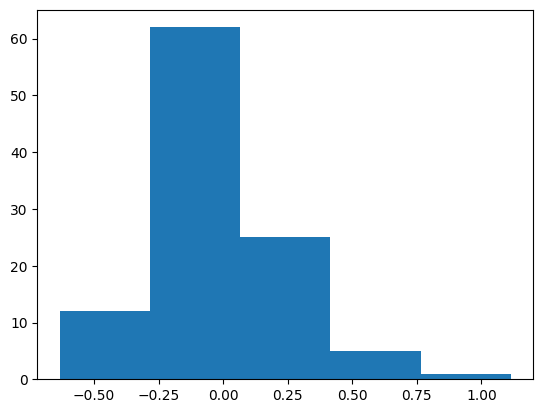

In [12]:
plt.hist( cols,bins=5 )
#plt.xlim([-1,2])

So it looks like these can be faaairly well behaved, described as some gaussian and then a tail to redder. So could fit one of these for each subclass? Then (i) fit a gaussian + exponential for each class (ii) record for each template the g-r color and the difference compared with the gaussian peak. This will be the initial Ebv diff. (iii) When simulating, draw a value from the combined guass + exp as the observed peak color (iv) set the template host color to this value and use for simulations.

In [13]:
def iqr_filter(data, k=1.5):
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return data[(data >= lower) & (data <= upper)]
def central_mask(data, lower_pct=5, upper_pct=95):
    lo, hi = np.percentile(data, [lower_pct, upper_pct])
    return data[(data >= lo) & (data <= hi)]

In [14]:
len(cols)

105

In [15]:
q1, q3 = np.percentile(cols, [25, 75])

In [16]:
d1 = np.array(cols)[np.array(cols)>-np.inf]

In [17]:
len(d1)

105

In [18]:
# Below follows a recommendation for asymmetric rejection, probably cannot claim ..
# Step 1: remove extreme garbage only
d2 = iqr_filter(d1, k=3)

In [19]:
len(d2)

104

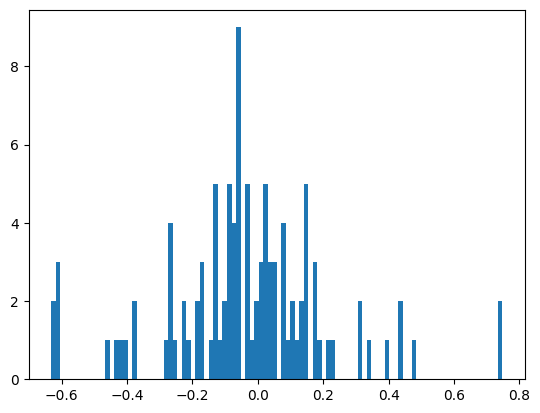

In [20]:
_ = plt.hist(d2,bins=100)

In [21]:
core = central_mask(d2, 5, 95)

In [22]:
len(core)

92

In [23]:
mu, sigma = np.mean(core), np.std(core)

In [24]:
print(mu, sigma)

-0.038157279258884784 0.16186504423037767


In [25]:
# Step 3: asymmetric clipping
d3 = d2[(d2 > mu - 5*sigma) & (d2 < mu + 5*sigma)]

In [26]:
len(d3)

104

(array([ 5.,  6.,  8., 20., 35., 19.,  4.,  4.,  1.,  2.]),
 array([-0.63226768, -0.4943445 , -0.35642132, -0.21849814, -0.08057496,
         0.05734822,  0.1952714 ,  0.33319458,  0.47111776,  0.60904094,
         0.74696412]),
 <BarContainer object of 10 artists>)

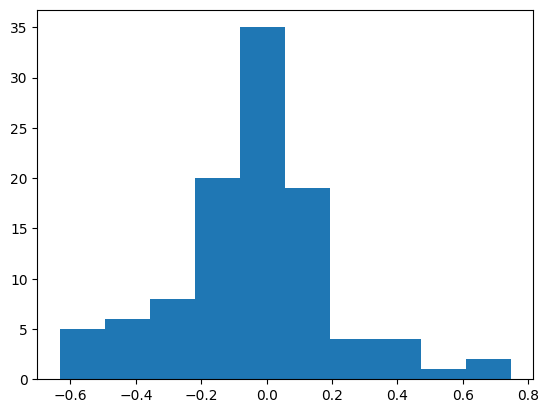

In [27]:
plt.hist( d3)

In [28]:
# What are we running with
#mydata = d1      # Only rempve Nan
#mydata = d2     # Mild filtering
mydata = d3     # Five sigma rejection


In [29]:

def fit_emg_and_store(data, model_name, col1, col2, outfile="warptemplate_color_fits.csv"):
    # Fit
    K, loc, scale = exponnorm.fit(data)

    # Create row
    result = {
        "model": model_name,
        "K": K,
        "loc": loc,
        "scale": scale,
        "color1": col1,
        "color2": col2,
        "n": len(data)
    }
    result["timestamp"] = datetime.utcnow().isoformat()

    # Convert to DataFrame
    df = pd.DataFrame([result])

    # Append to file
    file = Path(outfile)
    if file.exists():
        df.to_csv(file, mode="a", header=False, index=False)
    else:
        df.to_csv(file, index=False)

    return K, loc, scale

In [30]:
K, loc, scale = fit_emg_and_store(mydata, warpclasses[template_class_id], colband[0], colband[1] )

In [31]:
print(K, loc, scale)

0.602510399108125 -0.16388785008418136 0.21102028603801715


In [32]:
# Construct how many bins
if len(mydata)<30:
    bins = 5
elif len(mydata)<120:
    bins = 10
else:
    bins = 20

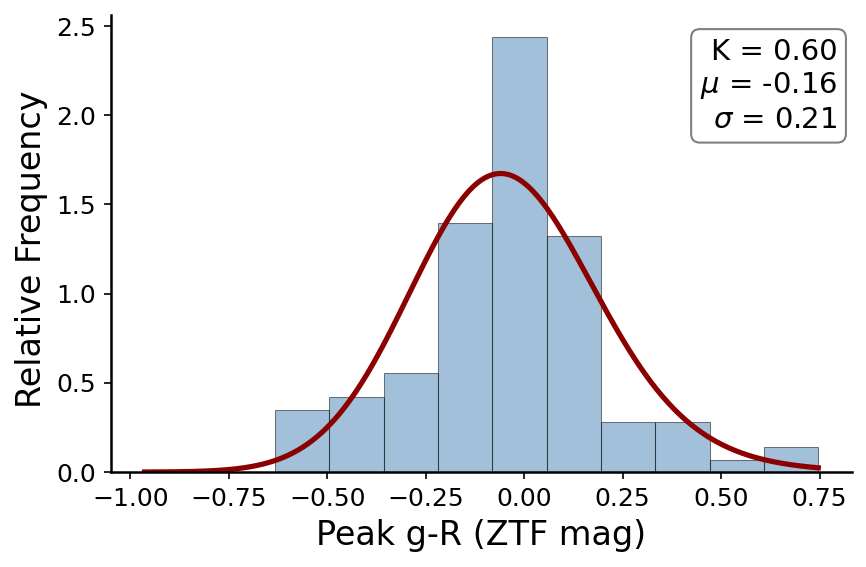

In [33]:

# Plot ranges
s, e = min(mydata), max(mydata)

s = min(s, loc-0.8)
e = max(e, loc+0.8)


# -------------------
# Smooth PDF
# -------------------
x = np.linspace(s, e, 1000)
pdf = exponnorm.pdf(x, K, loc=loc, scale=scale)

# -------------------
# Style (publication-ready)
# -------------------
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
    "figure.dpi": 150,
})

fig, ax = plt.subplots(figsize=(6, 4))

# Histogram
ax.hist(mydata, bins=bins, density=True,
        alpha=0.5, color="steelblue",
        edgecolor="black", linewidth=0.5,
        label="Data")

# Fit curve
ax.plot(x, pdf, color="darkred", lw=2.5,
        label="EMG fit")

# Labels
ax.set_xlabel("Peak g-R (ZTF mag)")
ax.set_ylabel("Relative Frequency ")

# Legend
#ax.legend(frameon=False)

# Clean up spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

text = (
    f"K = {K:.2f}\n"
    f"$\\mu$ = {loc:.2f}\n"
    f"$\\sigma$ = {scale:.2f}"
)

ax.text(0.98, 0.95, text,
        transform=ax.transAxes,
        ha="right", va="top",
        bbox=dict(boxstyle="round", fc="white", ec="gray"))


# Tight layout
plt.tight_layout()

if template_class_id == 4:
    plt.savefig("/Users/jnordin/tmp/warpfigs/emg_fit_SN Ibc.png", bbox_inches="tight",dpi=300)
else:
    plt.savefig("/Users/jnordin/tmp/warpfigs/emg_fit_{}.png".format(warpclasses[template_class_id]), bbox_inches="tight",dpi=300)

plt.show()

In [34]:
rng = np.random.default_rng(42)
samples = exponnorm.rvs(K, loc=loc, scale=scale, size=10000, random_state=rng)

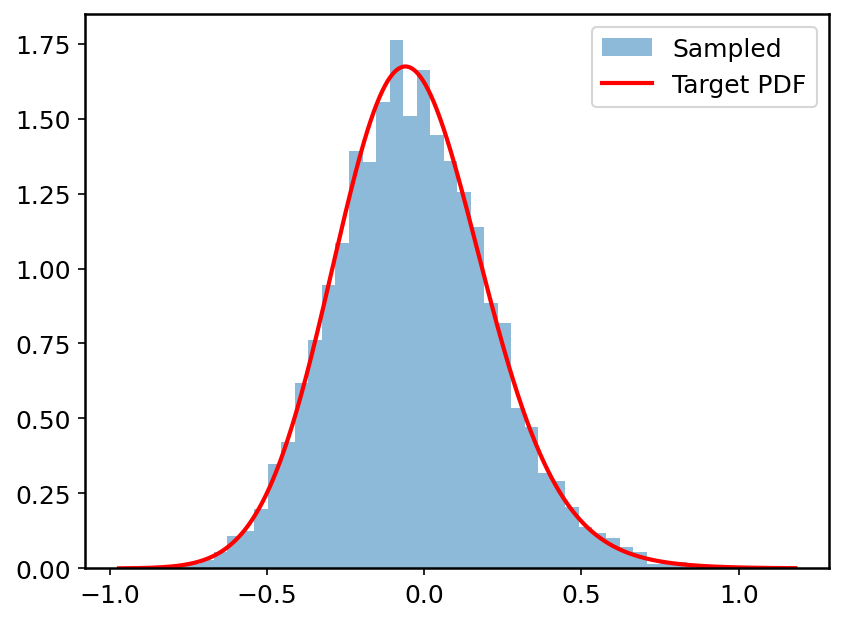

In [35]:
x = np.linspace(min(samples), max(samples), 1000)
pdf = exponnorm.pdf(x, K, loc=loc, scale=scale)

plt.hist(samples, bins=50, density=True, alpha=0.5, label="Sampled")
plt.plot(x, pdf, 'r-', lw=2, label="Target PDF")
plt.legend()
plt.show()

In [36]:
modcol = {'model': 'SN Ib',
 'K': 0.9079106174117336,
 'loc': 0.1250977286061127,
 'scale': 0.1514897618587996,
 'color1': 'ztfg',
 'color2': 'ztfr'}

In [37]:
import random
import matplotlib.pyplot as plt
from scipy.stats import exponnorm

In [38]:
rng = random.Random(41)

In [39]:
K, loc, scale = modcol['K'], modcol['loc'], modcol['scale']

In [40]:
emg_dist = exponnorm(K, loc, scale)

In [41]:
d2 = emg_dist.rvs(size=1000000, random_state=41)

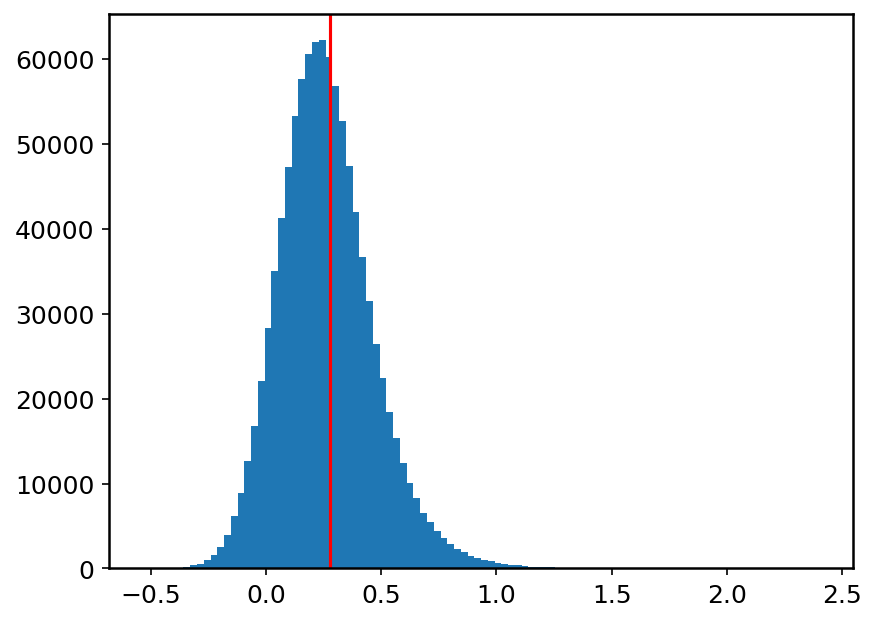

In [42]:
_ = plt.hist(d2,bins=100)
plt.axvline(x=loc+scale,color='red')

In [43]:
# Ok, so at this stage (after hormanize) we know that the color is at loc. We now wish to determine the 
# E(B-V) dust-like correction which is required to reach this value. 

In [44]:
exponnorm??

Signature:       exponnorm(*args, **kwds)
Type:            exponnorm_gen
String form:     <scipy.stats._continuous_distns.exponnorm_gen object at 0x131cd67d0>
File:            /opt/homebrew/Caskroom/miniconda/base/envs/ampelFeb25/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py
Source:         
class exponnorm_gen(rv_continuous):
    r"""An exponentially modified Normal continuous random variable.

    Also known as the exponentially modified Gaussian distribution [1]_.

    %(before_notes)s

    Notes
    -----
    The probability density function for `exponnorm` is:

    .. math::

        f(x, K) = \frac{1}{2K} \exp\left(\frac{1}{2 K^2} - x / K \right)
                  \text{erfc}\left(-\frac{x - 1/K}{\sqrt{2}}\right)

    where :math:`x` is a real number and :math:`K > 0`.

    It can be thought of as the sum of a standard normal random variable
    and an independent exponentially distributed random variable with rate
    ``1/K``.

    %(after_notes)s

    An altern